### 6/23/26 just checking to see if the output is normal

## Background

The goal of this project is to validate diagnostics for calculating numerical mixing through use of a water mass transformation framework. This suspected relationship is outlined in Appendix A of [Global observational estimates of thermohaline transformations by interior ocean mixing](https://doi.org/10.1175/JPO-D-25-0265.1) (Castro et al., 2026). 

Note that a general equation for the diascalar material transformation for a process $P$ for a water mass $\mathcal{M}$ defined to be all tracer $\lambda$ values greater than $\tilde \lambda$. The convergence of a flux $\mathcal{F} = \nabla \cdot \mathbf{F}$.

$$
    \mathcal{G}_{\ge}^{\text{(P)}} = \int_{\mathcal{A_R}(\tilde\lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \mathcal{F} \, \text{d}S = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
$$

And the subsequent diascalar material transformation demonstrating a relationship between mixing calculated as a convergence of a diffusive flux and mixing calculated as tracer variance decay is

*tbh, idk if this is the equation they use, but this is the equation I derived in my advancement proposal*
$$
\begin{equation}
\mathcal{G}^{\text{(phy)}} = \underbrace{\int_{\mathcal{A_R}(\tilde \lambda, t)} - \frac{\rho}{\vert \nabla \lambda \vert} \left(- \nabla \cdot \left(-\kappa_{phy} \nabla \lambda\right)\right) \, \text{d}S}_{\text{mixing as conv. of diff. flux}} = \underbrace{-\frac{1}{2} \frac{\partial^2}{\partial \tilde\lambda^2}\left[ \int_{\Omega(\tilde\lambda ,t)} \rho \left( 2 \kappa_{phy} \vert\vert \nabla \lambda \vert\vert^2\right) \, \text{d}V\right]}_{\text{mixing as var. decay}} 
\tag{2}
\end{equation}
$$ 


While Castro et al. describes a relationship between the convergence of a diffusive tracer flux and tracer variance decay for *phyiscal* mixing, we propose to look at *numerical* mixing through a similar framework. This relationship would look very similar to Equation 2, but our we would instead be solving for the term $\mathcal{G}^{\text{(num)}}$ and the diffusivities would be $\kappa_{num}$ rather than $\kappa_{phy}$. 

### Mixing as convergence of a diffusive flux
We quickly run into a problem, which is that $\kappa_{num}$ is unknown when calculating the nuemrical mixing as the convergence of a diffusive flux. Recall that $\kappa_{phy}$ comes from a prescribed background diffusivity. In which case, we need a different way to calculate $\mathcal{G}^{\text{(num)}}$. We propose to do so using the WMT budget residual.

$$
\begin{align}
    \partial_t{\mathcal{M}} &= \Psi + \mathcal{S} + \mathcal{G^{\text{(BF)}}} + \mathcal{G^{\text{(phy)}}} + \mathcal{G^{\text{(num)}}} \\
    \implies \mathcal{G^{\text{(num)}}} & = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}}
    \tag{3}
\end{align} 
$$

### Mixing as tracer variance decay
We *can*, however, calculate a $\kappa_{num}$ when thinking about numerical mixing through the perspective of tracer variance decay, if we use the Discrete Varaince Decay (DVD) algorithm.
Let 
$$
\begin{equation}
	\chi^{\text{(num)}} = \underbrace{\frac{A\{\left(\lambda_i^n\right)^2\} -\left[A\{\lambda_i^n\}\right]^2}{\Delta t}}_{\text{DVD}} = \underbrace{-2 \kappa_{num}\frac{\left(\lambda_i^n - \lambda_{i-1}^n\right)^2}{(\Delta x)^2}}_{\substack{\text{discretized mixing}\\\text{as variance decay}}} \approx \underbrace{-2 \kappa_{num}\left(\frac{\partial \lambda}{\partial x}\right)^2}_{\substack{\text{continuous mixing}\\\text{as variance decay}}} \tag{4}
\end{equation}
$$

The $\kappa_{num}$ arises out of the mathematical manipulation of the advection operator to get the rest of thet algorithm.
$$
    \kappa_{num} = u\Delta x \left(1 - \frac{u \Delta t}{\Delta x}\right) \tag{5}
$$

The $\chi^{\text{(num)}}$ term is a tendency that can now be written in the WMT framework as 
$$
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
$$

### WMT relationship of numerical mixing as a budget residual and as tracer variance decay.
The following relationship (in terms of the WMT framework) between Equations 2 and 3 then emerges.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = \partial_t{\mathcal{M}} - \Psi + \mathcal{S} - \mathcal{G^{\text{(BF)}}} - \mathcal{G^{\text{(phy)}}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi \, \text{d}V\right] \tag{7}
\end{equation}
$$

*do NOT trust the signs in this argument, it depends on the direction you're integrating, and I'm sure I have several sign errors rn*

In [319]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid

### Open files & visualize raw data

In [321]:
# filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
# ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
# ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
# ds_wmt = xr.open_dataset(filepath + 'analysis_members/10km_channel_WMT_Monthly.0001-01-01.nc')
# mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
# descriptor = mosaic.Descriptor(mesh, use_latlon=False)

In [324]:
filepath = '/pscratch/sd/k/kuyeda/WMT_DVD/bichan/10km/'
ds_output = xr.open_dataset(filepath + '10km_channel_output.nc')
ds_dvd = xr.open_dataset(filepath + 'analysis_members/10km_channel_DVD.0001-01-01.nc')
mesh = xr.open_dataset(filepath + '10km_channel_init.nc')
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

In [327]:
for i in ds_output.data_vars:
    if 'Mix' in i:
        print(i)

temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency


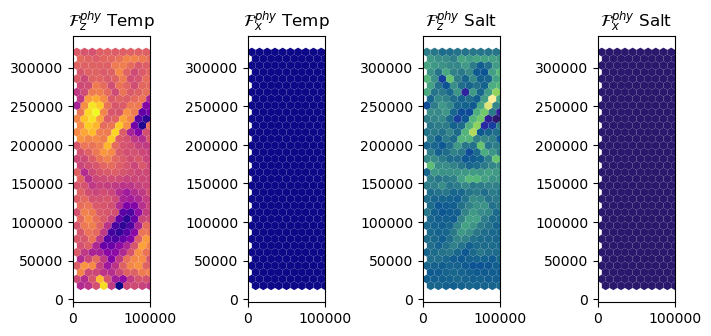

In [333]:
fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))

mosaic.polypcolor(ax[0],descriptor, ds_output.temperatureVertMixTendency.isel(Time=300, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[1],descriptor, ds_output.temperatureHorMixTendency.isel(Time=300, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[2],descriptor, ds_output.salinityVertMixTendency.isel(Time=300, nVertLevels=1),cmap='cmo.haline')
mosaic.polypcolor(ax[3],descriptor, ds_output.salinityHorMixTendency.isel(Time=300, nVertLevels=0),cmap='cmo.haline')
ax[0].set_title(r'$\mathcal{F}^{phy}_{z}$ Temp')
ax[1].set_title(r'$\mathcal{F}^{phy}_{x}$ Temp')
ax[2].set_title(r'$\mathcal{F}^{phy}_{z}$ Salt')
ax[3].set_title(r'$\mathcal{F}^{phy}_{x}$ Salt')

for i in range(0,4):
    ax[i].set_aspect(1.0)

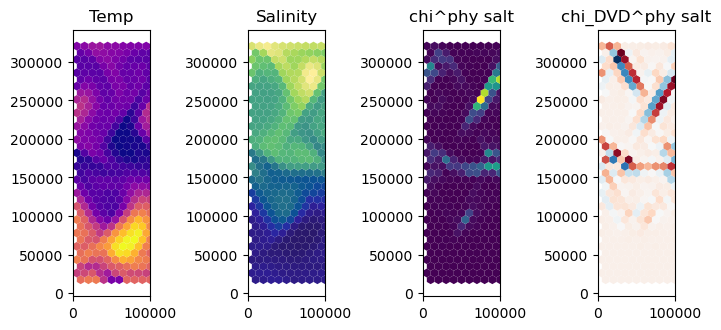

In [334]:
fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))


#mosaic.polypcolor(ax[0,0], descriptor, region00_plan.isel(Time = time_idx), cmap='RdBu_r', vmin=-cbar_value, vmax=cbar_value)
mosaic.polypcolor(ax[0],descriptor, ds_output.temperature.isel(Time=300, nVertLevels=0), cmap='plasma')
mosaic.polypcolor(ax[1],descriptor, ds_output.salinity.isel(Time=300, nVertLevels=0), cmap='cmo.haline')
mosaic.polypcolor(ax[2],descriptor, ds_dvd.chiPhyVerSalt.isel(Time=300, nVertLevelsP1=1))
mosaic.polypcolor(ax[3],descriptor, ds_dvd.chiSpurSaltBR08.isel(Time=300, nVertLevels=0),cmap='RdBu_r')
ax[0].set_title('Temp')
ax[1].set_title('Salinity')
ax[2].set_title('chi^phy salt')
ax[3].set_title('chi_DVD^phy salt')

for i in range(0,4):
    ax[i].set_aspect(1.0)

## Explanation of data


|Dataset Name|Description|
|--| --|
|`ds_output` | standard output variables (T, S, velo)|
|`ds_dvd` | $\chi^{\text{(phy)}}$ and $\chi^{\text{(num)}}$ from DVD alg.|
|`ds_output` | $\mathcal{F} \,; [^\circ C s^{-1}]$ ; conv. of diff. flux |
|`mesh` | grid variables (cellsOnEdge, etc) |

>- Simulations were run with a linear equation of state such that $\rho_0 = 1027 \, kg/m^3$ $\leftarrow$ CHECK THIS 
>- No prescribed horizontal mixing $\kappa_{phy,x} = 0$, so we expect `TracerHorMixTendency` to be 0 (`ds_output` dataset).
>- Vertical mixing is prescribed using KPP where the background diffusivity is $\kappa_{phy,z} = 10e-5 \, m^2s^{-1}$.
>- The background viscosity is set to $\nu = 10e-4 \, m^2 s^{-1}$.
>- Only wind stress forcing is prescribed.
>- The `TracerSurfaceFluxTendency` in the `ds_output` dataset is 0 because we do not have any boundary forcing that would introduce tracers at the surface.

The $\mathcal{F}$ and $\chi$ outputs require that we calculate $\mathcal{G}^{\text{(phy)}}$ and $\mathcal{G}^{\text{(num)}}$ offline. The following math is necessary.

*Recall that in order to calculate the residual, we need to directly calculate all other terms in the budget*

We need to plug in $\mathcal{F}$ (`TracerVertMixTendency`) into Equation 1.
$$
\begin{equation}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] \tag{1}
\end{equation}
$$

We need to plug in $\chi^{\text{(num)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(num)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(num)}} \, \text{d}V\right] \tag{6}
\end{equation}
$$

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$

## Calculate $\mathcal{G}^{\text{(phy)}}$ from convergence of a diffusive flux

The discretized version of Equation 1 is

$$
\begin{align}
    \mathcal{G}_{\ge}^{\text{(phy)}} = \frac{\partial}{\partial \tilde \lambda} \left[ \int_{\Omega(\tilde\lambda, t)} -\rho \mathcal{F} \,\text{d} V\right] &= \frac{\partial}{\partial \tilde\lambda} \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]  \\
    &=  \left(\left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i+1}} -  \left[ \sum_{z=1}^K \sum_{y=1}^L \sum_{x=1}^{M} \rho \mathcal{F}_{(x,y,z)} \, \text{d}x \, \text{d}y \, \text{d}z \right]_{\tilde\lambda_{i}}\right) \times \frac{1}{\tilde\lambda_{i} - \tilde\lambda_{i+1}}
\end{align}
$$
for $(x,y,z) \in \{\lambda \ge \tilde\lambda^\prime\}$.

*Note that we take are looking at $\lambda_i - \lambda_{i+1}$ rather than the other way around. This is because we defined $\mathcal{M}_\ge$ to account for all salinities **greater** than the threshold lambda $\tilde\lambda$. So we are looking from the saltier value to a fresher value (decreasing $\lambda$), rather than a traditional increase.*

### Step by step explanation
1. Take the mass tendency (why we multiply by $\rho$) weighted by volume $\left( \text{d}V \right)$ for every grid cell. This is the *integrand*.
2. Regrid from z-coordinates to tracer coordinates
3. For every tracer class, take the sum of the integrand over all grid cells in that tracer class.
4. Calculate the discretized change in integrand (tendency) over change in tracer class. 

In [207]:
## SOMETHING IS WRONG I JUST DON'T KNOW WHAT YET

In [347]:
# calculate the integrand
time_idx = 15
rho_0 = 1026 # kg/m^3
dV = (mesh.areaCell * mesh.layerThickness).isel(Time=0)

# take the mean over time
integrand = ds_output.salinityVertMixTendency.mean(dim='Time') * rho_0 * dV


In [516]:
# set up salinity data to be target coords
# not for this set up, but good practice in case there's topography
# fill the bottom cell with the same value as the one above it (so it is no longer a nan)
ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# interpolate data onto nVertLevelsP1 
grid = Grid(ds_output, coords={'Z': {'center': 'nVertLevels', 'outer':'nVertLevelsP1'}}, periodic = False, autoparse_metadata=False)

# interpolate
ds_output['salinity_P1'] = grid.interp(ds_output.salinity, 'Z', boundary='extend')

# crudely calculate target coords
# +2 to ensure that the upper and lower bins have a Gphy = 0
lower_bound = ds_output.salinity_P1.mean(dim='Time').min() - 2
upper_bound = ds_output.salinity_P1.mean(dim='Time').max() + 2
target_coords = np.arange(lower_bound,upper_bound,1)
dlambda = target_coords[1] - target_coords[0]

# transform
ds_output_salinity_mix_tendencyZ_transformed = grid.transform(integrand,
                                                             'Z',
                                                             target_coords,
                                                             method= 'conservative',
                                                             target_data = ds_output.salinity_P1.mean(dim='Time'))
                                                             # target_data = ds_output.salinity_P1.isel(Time=300))

In [517]:
# then calculate the derivative
# create an array
G_phy = np.zeros(len(target_coords))

for i in range(0,len(target_coords)-2):
    d_tracerMassFlux = ds_output_salinity_mix_tendencyZ_transformed[:,i].sum() - ds_output_salinity_mix_tendencyZ_transformed[:,i+1].sum()
    d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
    G_phy[i] = d_tracerMassFlux_dlambda
    
    

## Tentative $\mathcal{G}^{\text{(phy)}}$ plots 
>- We have define our water mass to be all waters with $\lambda \ge \tilde\lambda$
>- This means we should integrate (cumsum) from our greatest salinity values to our lowest.
>- By the time we reach $\tilde\lambda = \tilde\lambda_{freshest}$, then the entire water column will be accounted for.
>- $\mathcal{M}_{\ge}$ increases in size when "its mass transfports are net convergent and therefore increase the size of $\mathcal{M}_\ge$ defined to have salinity values greater than the threshold $\tilde\lambda$."
>>- This is based on the definition of WMT from Drake et al., 2025.
>>- This would mean that **positive** values of $\mathcal{G}^{\text{(phy)}}$ **increase salinity** (fresh water gets mixed into a saltier density class $\mathcal{M}_\ge$)
>>- And **negative** values of $\mathcal{G}^{\text{(phy)}}$ **decrease salinity** (salty water gets mixed OUT of $\mathcal{M}_\ge$)
>- Looking at the $\mathcal{G}^{\text{(phy)}}$ cumsum graph (left):
>- We see that salty density classes $\lambda \gtrsim 35 \, g/kg \times 10e-3$ are getting fresher $\mathcal{G}^{\text{(phy)}} < 0$
>- We see that fresher density classes $\lambda \lesssim 35 \, g/kg \times 10e-3$ are getting saltier $\mathcal{G}^{\text{(phy)}} > 0$
>>- This suggests mixing across all density classes?
>- I am less certain how to interpret the others $\mathcal{G}^{\text{(phy)}}$ figure. It looks like the most mixing is occurring at that $\lambda = 35$ interface ($\max \mathcal{G}^{\text{(phy)}}$)

Text(0.5, 0.98, 'Time-averaged diascalar material transformation  $\\mathcal{G}^{\\text{(phy)}}$')

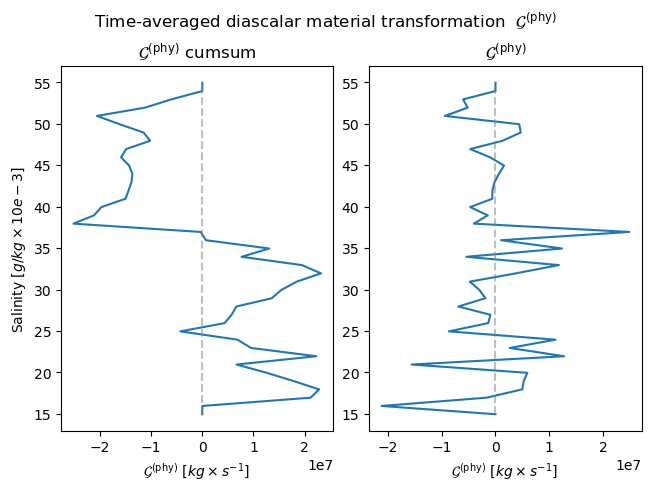

In [518]:
fig, ax = plt.subplots(nrows=1,ncols=2,constrained_layout=True)
# cumsum from bottom (lowest salinity class) to top (highest salinity class)
# we need to perform a reverse cumsum because our water mass M is defined to be all values GREATER Than threshold lambda

rev_G_phy = np.flipud(G_phy)
cumsum_rev_G_phy = np.cumsum(rev_G_phy)
# reverse back to match highest salinity value to lowest cumsum value
cumsum_G_phy = np.flipud(cumsum_rev_G_phy)

ax[0].plot(cumsum_G_phy, target_coords)
ax[0].set_title(r'$\mathcal{G}^{\text{(phy)}}$ cumsum')
ax[1].plot(G_phy, target_coords)
ax[1].set_title(r'$\mathcal{G}^{\text{(phy)}}$')
ax[0].vlines(0,ymin=target_coords[0], ymax = target_coords[-1], color='gray', alpha=0.5,linestyle='dashed')
ax[1].vlines(0,ymin=target_coords[0], ymax = target_coords[-1], color='gray', alpha=0.5,linestyle='dashed')

ax[0].set_xlabel(r'$\mathcal{G}^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')
ax[0].set_ylabel(r'Salinity $\left[ g/kg \times 10e-3\right]$')

ax[1].set_xlabel(r'$\mathcal{G}^{\text{(phy)}} \,\, \left[kg \times s^{-1}\right]$ ')

fig.suptitle(r'Time-averaged diascalar material transformation  $\mathcal{G}^{\text{(phy)}}$')

## $\mathcal{G}^{\text{(phy)}}$ calculated from convergence of a diffusive flux

To make a plan view plot of at different isosurfaces, preserve `nCells` when calculating the tracerMassFlux derivative. 

Put the derivative onto salinity coords (since we're differencing, move from edge to center)

In [535]:
local_G_phy = []
for i in range(0,len(target_coords)-2):
    d_tracerMassFlux = ds_output_salinity_mix_tendencyZ_transformed[:,i] - ds_output_salinity_mix_tendencyZ_transformed[:,i+1]
    d_tracerMassFlux_dlambda = d_tracerMassFlux / dlambda
    local_G_phy.append(d_tracerMassFlux_dlambda)

# we've calculated the local G_phy for every isohaline surface defined in target_coords
# this is messy, because idk what salinity surface exactly we've calculated onto
# this is crude, but I'm just going to average the salinity_P1 data and put this differenced data onto there
salinity_remap = target_coords[1:-1]
local_G_phy_ds = xr.concat(local_G_phy, dim = 'salinity').assign_coords(salinity = salinity_remap)

Text(0.5, 0.63, '$\\mathcal{G}^{\\text{(phy)}}$ at 4 different isohaline surfaces')

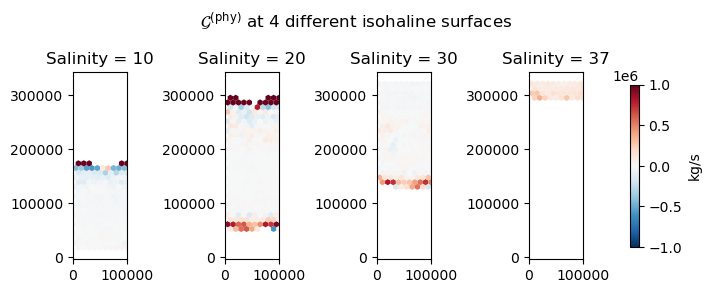

In [589]:
fig,ax = plt.subplots(nrows=1,ncols=4,constrained_layout=True,figsize=(7,12))

mosaic.polypcolor(ax[0],descriptor, local_G_phy_ds.isel(salinity=10),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
mosaic.polypcolor(ax[1],descriptor, local_G_phy_ds.isel(salinity=20),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
mosaic.polypcolor(ax[2],descriptor, local_G_phy_ds.isel(salinity=30),cmap='RdBu_r',vmin=-1e6,vmax=1e6)
c = mosaic.polypcolor(ax[3],descriptor, local_G_phy_ds.isel(salinity=37),cmap='RdBu_r',vmin=-1e6,vmax=1e6)

surfaces = [10, 20, 30, 37]
for i in range(0,4):
    ax[i].set_aspect(1.0)
    ax[i].set_title(f'Salinity = {surfaces[i]}')

for i in range(1,4):
    ax[i].set_ylabel('')
    
fig.colorbar(c, ax=ax[3],label='kg/s')
fig.suptitle(r'$\mathcal{G}^{\text{(phy)}}$ at 4 different isohaline surfaces',y=0.63)

## Calculate $\mathcal{G}^{\text{(phy)}}$ from tracer variance decay

To compare physical mixing calculations, we plug in $\chi^{\text{(phy)}}$ into Equation 6.

$$
\begin{equation}
    \mathcal{G}^{\text{(phy)}} = -\frac{1}{2} \frac{\partial^2}{\partial \lambda^2} \left[ \int_{\Omega(\tilde\lambda,t)} \rho \chi^{\text{(phy)}} \, \text{d}V\right] \tag{8}
\end{equation}
$$